# Comparing Logistic Regression, KNN, and Decision Trees

### Table of contents
0. [Introduction](#0.-Introduction)
1. [Setup](#1.-Setup)
2. [Refitting all three models](#2.-Refitting-all-three-models)
3. [Comparing metrics](#3.-Comparing-metrics)
4. [ROC curves](#4.-ROC-curves)
5. [Comparing speed](#5.-Comparing-speed)
6. [Comparing interpretability](#6.-Comparing-interpretability)
7. [Decision boundary, visually](#7.-Decision-boundary,-visually)
8. [Week 4 summary](#8.-Week-4-summary)
9. [Exercises](#9.-Exercises)

## 0. Introduction

Four notebooks, three classifiers:
1. Logistic Regression, toy data (`01_logistic_regression_intro.ipynb`)
2. Logistic Regression, full scale and evaluation (`02_logistic_regression.ipynb`)
3. K-Nearest Neighbors (`03_knn.ipynb`)
4. Decision Trees (`04_decision_trees.ipynb`)

This notebook puts all three side by side on the same dataset and split, then closes the week with a summary and exercises.

## 1. Setup

Same load, split, scale as notebooks 2 to 4, repeated here so this notebook runs on its own.

In [1]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
df = data.frame
X = df.drop(columns="target")
y = df["target"]

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 2. Refitting all three models

Logistic Regression (notebook 2):

In [4]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=5000)
logreg.fit(X_train_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_scaled)

KNN (notebook 3), picking `k` by cross-validation:

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

k_values = range(1, 31)
cv_scores = [cross_val_score(KNeighborsClassifier(n_neighbors=k), X_train_scaled, y_train, cv=5).mean()
             for k in k_values]
best_k = k_values[int(np.argmax(cv_scores))]
print(f"best k = {best_k}")

best k = 8


In [6]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

Decision Tree (notebook 4):

In [7]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

## 3. Comparing metrics

Same dataset, same split, all three models.

In [8]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    "Logistic Regression": {
        "Accuracy": accuracy_score(y_test, y_pred_logreg),
        "Precision": precision_score(y_test, y_pred_logreg),
        "Recall": recall_score(y_test, y_pred_logreg),
        "F1-score": f1_score(y_test, y_pred_logreg),
    },
    f"KNN (k={best_k})": {
        "Accuracy": accuracy_score(y_test, y_pred_knn),
        "Precision": precision_score(y_test, y_pred_knn),
        "Recall": recall_score(y_test, y_pred_knn),
        "F1-score": f1_score(y_test, y_pred_knn),
    },
    "Decision Tree": {
        "Accuracy": accuracy_score(y_test, y_pred_tree),
        "Precision": precision_score(y_test, y_pred_tree),
        "Recall": recall_score(y_test, y_pred_tree),
        "F1-score": f1_score(y_test, y_pred_tree),
    },
})
comparison.round(4)

,Logistic Regression,KNN (k=8),Decision Tree
Accuracy,0.9825,0.9737,0.9386
Precision,0.9861,0.9726,0.9577
Recall,0.9861,0.9861,0.9444
F1-score,0.9861,0.9793,0.9510


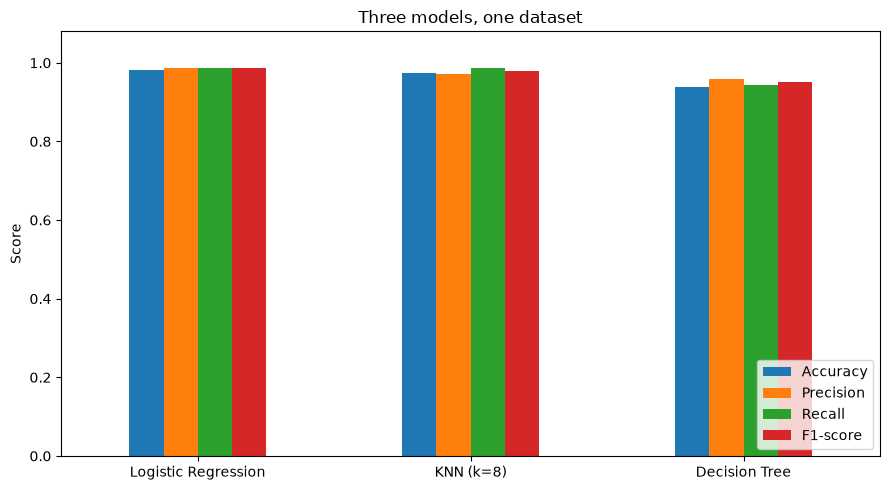

In [9]:
import matplotlib.pyplot as plt

comparison.T.plot(kind="bar", figsize=(9, 5), rot=0)
plt.ylabel("Score")
plt.ylim(0, 1.08)
plt.title("Three models, one dataset")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Logistic Regression and KNN are close on every metric. The single Decision Tree trails a bit, a direct, numeric look at the instability notebook 4 showed visually.

## 4. ROC curves

True positive rate vs. false positive rate, across every threshold, all three models at once.

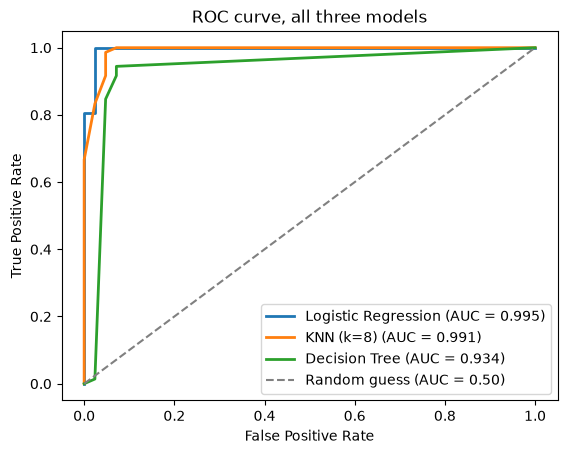

In [10]:
from sklearn.metrics import roc_curve, roc_auc_score

models_proba = {
    "Logistic Regression": logreg.predict_proba(X_test_scaled)[:, 1],
    f"KNN (k={best_k})": knn.predict_proba(X_test_scaled)[:, 1],
    "Decision Tree": tree.predict_proba(X_test)[:, 1],
}

for label, y_proba in models_proba.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, linewidth=2, label=f"{label} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random guess (AUC = 0.50)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve, all three models")
plt.legend(loc="lower right")
plt.show()

AUC: 0.995 for Logistic Regression, 0.991 for KNN, 0.934 for the Decision Tree, same ranking as the metrics table, now visible across every threshold at once, not just the default 0.5.

## 5. Comparing speed

In [11]:
%timeit logreg.predict(X_test_scaled)

140 μs ± 4.3 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [12]:
%timeit knn.predict(X_test_scaled)

3.51 ms ± 753 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [13]:
%timeit tree.predict(X_test)

662 μs ± 7.49 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


Logistic Regression and the Decision Tree predict almost instantly (a matrix multiplication, and a handful of comparisons). KNN is the slow one, since it recomputes distances to every training point at prediction time.

## 6. Comparing interpretability

- Logistic Regression: `.coef_` gives a number per feature, directly readable.
- Decision Tree: `plot_tree` shows the exact reasoning, split by split.
- KNN: no coefficients, no equation, nothing to read but the vote itself.

None of this makes one model "correct." It's exactly the kind of trade-off table next week's models, Random Forest and SVM, get added to.

## 7. Decision boundary, visually

Same synthetic 2D data used in notebook 4, all three models fit fresh and overlaid side by side.

In [14]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=300, noise=0.25, random_state=42)

In [15]:
def plot_boundary(ax, model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict_proba(grid)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 21), cmap="RdBu_r", alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu_r", edgecolors="white", linewidths=0.6, s=25)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

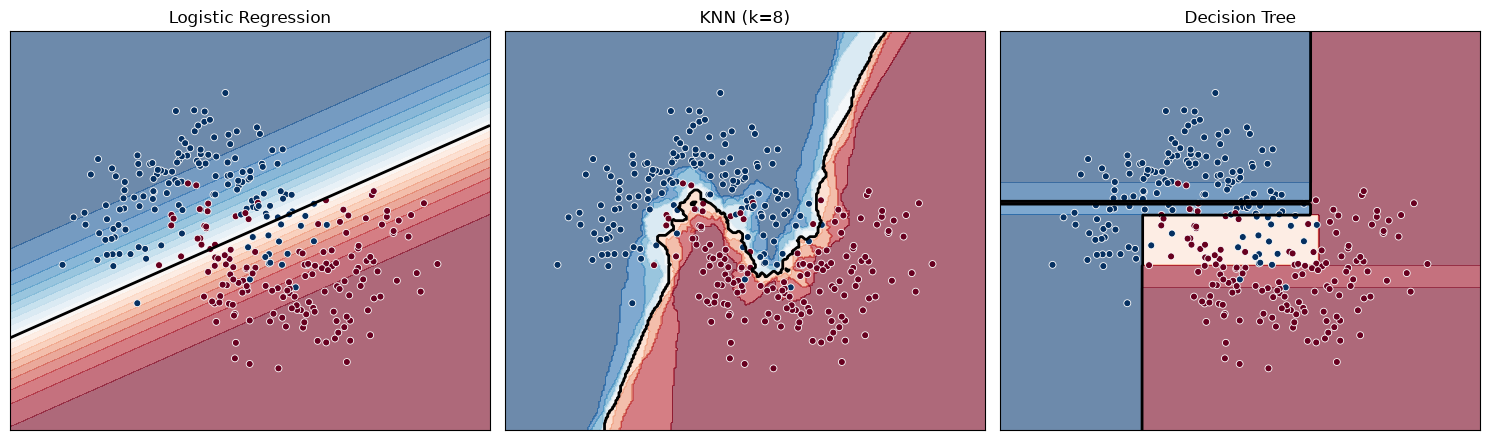

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
boundary_models = [
    (LogisticRegression(max_iter=5000), "Logistic Regression"),
    (KNeighborsClassifier(n_neighbors=best_k), f"KNN (k={best_k})"),
    (DecisionTreeClassifier(max_depth=4, random_state=42), "Decision Tree"),
]
for ax, (model, name) in zip(axes, boundary_models):
    model.fit(X_moons, y_moons)
    plot_boundary(ax, model, X_moons, y_moons, name)
plt.tight_layout()
plt.show()

Logistic Regression draws one straight line, missing the curve entirely. KNN traces the moon shape closely by voting locally. The Decision Tree carves the plane into axis-aligned rectangles, the same blocky shape from notebook 4's own decision boundary section.

## 8. Week 4 summary

- Classification predicts a category, not a continuous number. The useful underlying output is a probability, converted to a label with a threshold (default 0.5, not sacred).
- Logistic Regression feeds `z = w*x + b` through sigmoid; its decision boundary is always linear. Seen first on 10 points and 1 feature, then on 455 samples and 30 features.
- A model is meaningless without honest evaluation. Accuracy alone can mislead, especially under class imbalance. Precision, recall, F1, and ROC/AUC give the fuller picture.
- KNN learns no equation at all, just a vote among the `k` nearest neighbors. `k` is its complexity knob, and feature scaling is not optional.
- Decision Trees decide with sequential yes/no questions, minimizing Gini impurity at each split. The most inspectable model here, and the one needing no scaling, but the shakiest on its own.
- No model is universally best. The choice depends on data shape, need for interpretability, and speed. Next week: combining many trees into one model (Random Forest).

## 9. Exercises

1. Refit `LogisticRegression` (notebook 2) using only the 5 features with strongest correlation to the target. Compare accuracy, precision, and recall to the full 30-feature model. Was dropping 25 features costly? Plot both models' three metrics as a grouped bar chart, same style as section 3.

2. Using `logreg.predict_proba(X_test_scaled)`, find the threshold (steps of 0.05, 0.05 to 0.95) that maximizes recall on the malignant class (`pos_label=0`) while keeping its precision above 0.90. Report both metrics, and plot precision and recall against threshold, marking the one you chose. Then plot the confusion matrix at that threshold next to the Decision Tree's (`tree`, above): which one makes more false negatives on malignant?

3. Repeat notebook 3's k-selection restricted to `metric="manhattan"`. Does the best `k` change? Does the best CV accuracy? Plot CV accuracy against `k`, same style as notebook 3's elbow curve.

4. Using `cross_val_score`, find the best `max_depth` for the Decision Tree among `[2, 3, 4, 5, 6, 8, 10, None]` with `cv=5`. Compare to the fixed `max_depth=4` tree used above. Plot CV accuracy against `max_depth` (treat `None` as, say, 12 so it fits on the axis).
5. Using the imbalanced data from notebook 2 section 8.2, train a real `LogisticRegression` (not `DummyClassifier`). Generate matching features, for example `X_imbalanced = np.random.default_rng(42).normal(size=(1000, 2))` related to `y_imbalanced`. Does it beat the "always healthy" baseline on recall? By how much? Plot both models' confusion matrices side by side.
6. Change `k` from 5 to 3 in notebook 3's toy example and recompute the vote by hand. Does the prediction change?
7. Add one more day to the Play Tennis table (notebook 4) with weather and label of your choice, refit, and re-plot. Did the tree structure change?
8. A new dataset, start to finish. Load `sklearn.datasets.load_wine(as_frame=True)`, a 3-class dataset. Split with `stratify`, scale, fit all three models unchanged, and report test accuracy. Notice nothing about the model-fitting code had to change for 3 classes instead of 2. Plot the three models' test accuracy as a bar chart.